# 🏠 Nashville Housing — Exploratory Data Analysis

> **Author:** Noah Asgodom
> **Dataset:** Nashville Housing (Cleaned)  
> **Tools:** Python · Pandas · Matplotlib · Seaborn  
> **Goal:** Surface pricing patterns, geographic trends, and feature relationships to guide downstream modelling and Power BI reporting.

---

## Notebook Structure

| Section | Content |
|---------|--------|
| 1 | Environment setup & data loading |
| 2 | Data profiling (shape, types, nulls, statistics) |
| 3 | Univariate analysis — SalePrice distribution |
| 4 | Geographic analysis — Average SalePrice by City |
| 5 | Bivariate analysis — TotalValue vs SalePrice |
| 6 | Temporal analysis — YearBuilt vs SalePrice |
| 7 | Categorical analysis — Bedrooms vs SalePrice |
| 8 | Correlation heatmap |
| 9 | Power BI export |

---
## ⚙️ Section 1 — Environment Setup & Data Loading

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 130,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

# ── Colour palette (consistent across all charts) ────────────────────────────
PRIMARY   = '#2C6E9B'   # steel blue
ACCENT    = '#E76F51'   # terracotta
NEUTRAL   = '#6C757D'   # slate grey
HIGHLIGHT = '#2A9D8F'   # teal

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = Path('data/processed')
VISUALS_DIR   = Path('visuals')
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Environment ready.')
print(f'   pandas  {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}')

✅ Environment ready.
   pandas  2.2.3  |  numpy 2.2.6  |  seaborn 0.13.2


In [3]:
# ── Load from Parquet  ─────────────────────────
parquet_path = PROCESSED_DIR / r'C:\Users\noahi\Documents\Git\Noah_Portofilio-\project_1\data\processed\nashville_housing_cleaned.parquet'
# csv_path     = PROCESSED_DIR / 'nashville_housing_cleaned.csv'

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    print(f'Loaded from Parquet: {parquet_path}')
elif csv_path.exists():
    df = pd.read_csv(csv_path, parse_dates=['SaleDate'])
    print(f'Loaded from CSV: {csv_path}')
else:
    raise FileNotFoundError(
        'No cleaned dataset found. '
        'Run the cleaning pipeline notebook first.'
    )

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded from Parquet: C:\Users\noahi\Documents\Git\Noah_Portofilio-\project_1\data\processed\nashville_housing_cleaned.parquet
Shape: 56,373 rows × 21 columns


---
## 🔍 Section 2 — Data Profiling

In [4]:
# ── First look ────────────────────────────────────────────────────────────────
print('── First 5 rows ────────────────────────────────────────────────────────')
display(df.head())

print('\n── Column types & non-null counts ─────────────────────────────────────')
df.info()

── First 5 rows ────────────────────────────────────────────────────────


,UniqueID,ParcelID,SaleDate,SalePrice,LegalReference,SoldAsVacant,PropertyStreet,PropertyCity,OwnerName,OwnerStreet,...,OwnerState,Acreage,TaxDistrict,LandValue,BuildingValue,TotalValue,YearBuilt,Bedrooms,FullBath,HalfBath
0,122,105 13 0 349.00,2013-01-02,225000.0,20130107-0001749,No,924 WALDKIRCH AVE,NASHVILLE,"THOMAS, JOHN HARRISON & CAMERON, VICTORIA RAYE",924 WALDKIRCH AVE,...,TN,0.18,URBAN SERVICES DISTRICT,140000.0,83400.0,245200.0,1940.0,2.0,1.0,0.0
1,189,142 09 0H 065.00,2013-01-02,135000.0,20130111-0003886,No,9135 SAWYER BROWN RD,NASHVILLE,None,None,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,204,159 00 0 261.00,2013-01-02,1365000.0,20130104-0001158,No,5442 GRANNY WHITE PIKE,BRENTWOOD,"HAMMAN, JACO INTER VIVOS REVOCABLE TRUST",5442 GRANNY WHITE PIKE,...,TN,1.99,GENERAL SERVICES DISTRICT,280800.0,1184700.0,1465500.0,2006.0,4.0,4.0,1.0
3,217,091 07 0 171.00,2013-01-02,50000.0,20130103-0001026,No,4806 KENTUCKY AVE,NASHVILLE,"NELSON, EUGENE",4806 KENTUCKY AVE,...,TN,0.17,URBAN SERVICES DISTRICT,45000.0,48200.0,93200.0,1918.0,3.0,1.0,0.0
4,251,042 07 0A 129.00,2013-01-02,51200.0,20130103-0000637,No,585 HERITAGE LN,MADISON,None,None,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN



── Column types & non-null counts ─────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56373 entries, 0 to 56372
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UniqueID        56373 non-null  int64  
 1   ParcelID        56373 non-null  object 
 2   SaleDate        56373 non-null  object 
 3   SalePrice       56373 non-null  float64
 4   LegalReference  56373 non-null  object 
 5   SoldAsVacant    56373 non-null  object 
 6   PropertyStreet  56373 non-null  object 
 7   PropertyCity    56373 non-null  object 
 8   OwnerName       25215 non-null  object 
 9   OwnerStreet     25969 non-null  object 
 10  OwnerCity       25969 non-null  object 
 11  OwnerState      25969 non-null  object 
 12  Acreage         25969 non-null  float64
 13  TaxDistrict     25969 non-null  object 
 14  LandValue       25969 non-null  float64
 15  BuildingValue   25969 non-null  float64
 16  Tot

In [5]:
# ── Missing value audit ───────────────────────────────────────────────────────
null_report = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'null_count'})
    .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(2))
    .query('null_count > 0')
    .sort_values('null_count', ascending=False)
    .reset_index(drop=True)
)

if null_report.empty:
    print('✅ No missing values detected.')
else:
    print(f'⚠️  {len(null_report)} columns have missing values:')
    display(null_report)

⚠️  13 columns have missing values:


,column,null_count,null_pct
0,HalfBath,32274,57.25
1,Bedrooms,32261,57.23
2,YearBuilt,32255,57.22
3,FullBath,32143,57.02
4,OwnerName,31158,55.27
5,Acreage,30404,53.93
6,OwnerState,30404,53.93
7,OwnerCity,30404,53.93
8,OwnerStreet,30404,53.93
9,TotalValue,30404,53.93


In [6]:
# ── Descriptive statistics (numerical columns only) ───────────────────────────
num_cols = ['SalePrice', 'TotalValue', 'LandValue', 'BuildingValue',
            'Bedrooms', 'YearBuilt', 'Acreage', 'FullBath', 'HalfBath']

# Keep only columns that actually exist in the dataset
num_cols = [c for c in num_cols if c in df.columns]

desc = (
    df[num_cols]
    .describe(percentiles=[.25, .50, .75, .95])
    .T
    .round(2)
)
display(desc)

,count,mean,std,min,25%,50%,75%,95%,max
SalePrice,56373.0,327523.01,930657.32,50.00,135000.00,205700.00,329000.00,759900.00,54278060.00
TotalValue,25969.0,232558.97,281266.30,100.00,102800.00,148600.00,268600.00,673300.00,13940400.00
LandValue,25969.0,69144.98,106117.40,100.00,21000.00,28800.00,60000.00,250000.00,2772000.00
BuildingValue,25969.0,160888.72,206954.67,0.00,76000.00,111400.00,180800.00,448520.00,12971800.00
Bedrooms,24112.0,3.09,0.85,0.00,3.00,3.00,3.00,4.00,11.00
YearBuilt,24118.0,1963.73,26.54,1799.00,1948.00,1960.00,1983.00,2015.00,2017.00
Acreage,25969.0,0.50,1.57,0.01,0.18,0.27,0.45,1.26,160.06
FullBath,24230.0,1.89,0.96,0.00,1.00,2.00,2.00,4.00,10.00
HalfBath,24099.0,0.28,0.49,0.00,0.00,0.00,1.00,1.00,3.00


In [7]:
# ── Remove extreme outliers for EDA only (keep raw df untouched) ──────────────
# Outliers skew axis ranges and hide the bulk of the distribution.
# We cap at the 99th percentile of SalePrice for visualisation purposes only.
P99 = df['SalePrice'].quantile(0.99)
eda = df[df['SalePrice'] <= P99].copy()

removed = len(df) - len(eda)
print(f'EDA subset: {len(eda):,} rows  '
      f'({removed} extreme outliers above ${P99:,.0f} excluded from charts only)')

EDA subset: 55,830 rows  (543 extreme outliers above $1,935,000 excluded from charts only)


---
## 📊 Section 3 — Univariate Analysis: SalePrice Distribution

**What to look for:** shape (normal vs skewed), presence of outliers, and the typical price range for Nashville properties.

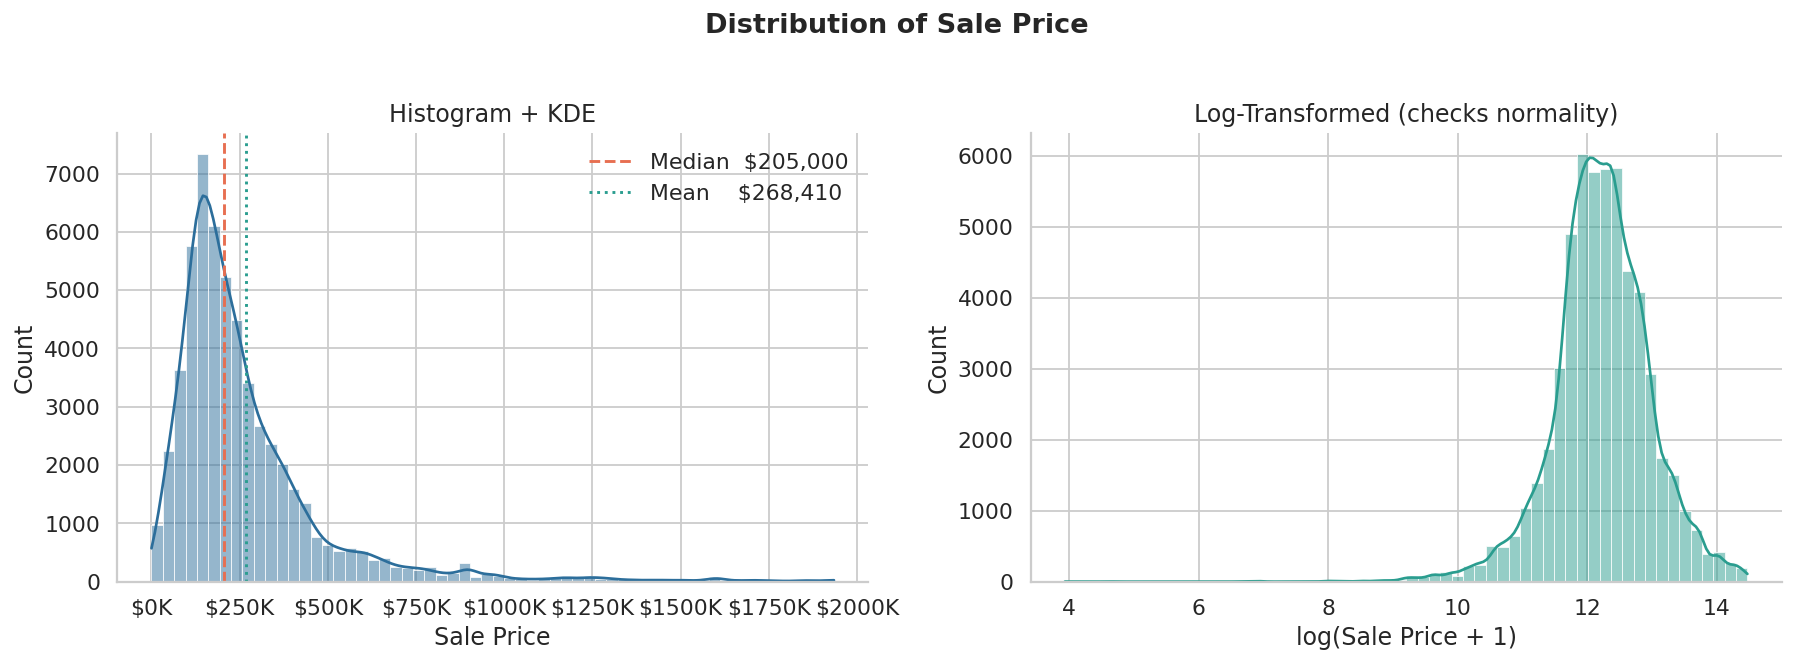

Skewness: 2.93  (right-skewed — long upper tail)

📌 Insight: Sale prices are right-skewed — a small number of high-value properties pull the mean above the median. The log-transformed chart shows whether the bulk of sales follows a near-normal distribution, which is typical in residential real-estate markets.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Sale Price', fontsize=15, fontweight='bold', y=1.02)

# ── Left: histogram + KDE ────────────────────────────────────────────────────
ax = axes[0]
sns.histplot(
    eda['SalePrice'], bins=60, kde=True,
    color=PRIMARY, edgecolor='white', linewidth=0.4,
    ax=ax
)
ax.axvline(eda['SalePrice'].median(), color=ACCENT, linestyle='--',
           linewidth=1.6, label=f"Median  ${eda['SalePrice'].median():,.0f}")
ax.axvline(eda['SalePrice'].mean(),   color=HIGHLIGHT, linestyle=':',
           linewidth=1.6, label=f"Mean    ${eda['SalePrice'].mean():,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Sale Price')
ax.set_ylabel('Count')
ax.set_title('Histogram + KDE')
ax.legend(frameon=False)

# ── Right: log-scale histogram (reveals shape at all price levels) ───────────
ax2 = axes[1]
sns.histplot(
    np.log1p(eda['SalePrice']), bins=60, kde=True,
    color=HIGHLIGHT, edgecolor='white', linewidth=0.4,
    ax=ax2
)
ax2.set_xlabel('log(Sale Price + 1)')
ax2.set_ylabel('Count')
ax2.set_title('Log-Transformed (checks normality)')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_saleprice_distribution.png', bbox_inches='tight')
plt.show()

skew = eda['SalePrice'].skew()
print(f'Skewness: {skew:.2f}  ({"right-skewed — long upper tail" if skew > 1 else "approximately normal"})')
print()
print('📌 Insight: Sale prices are right-skewed — a small number of high-value '
      'properties pull the mean above the median. The log-transformed chart '
      'shows whether the bulk of sales follows a near-normal distribution, '
      'which is typical in residential real-estate markets.')

---
## 🗺️ Section 4 — Geographic Analysis: Average SalePrice by City

**What to look for:** which cities command premium prices vs affordable pockets; how many cities make up most of the transaction volume.

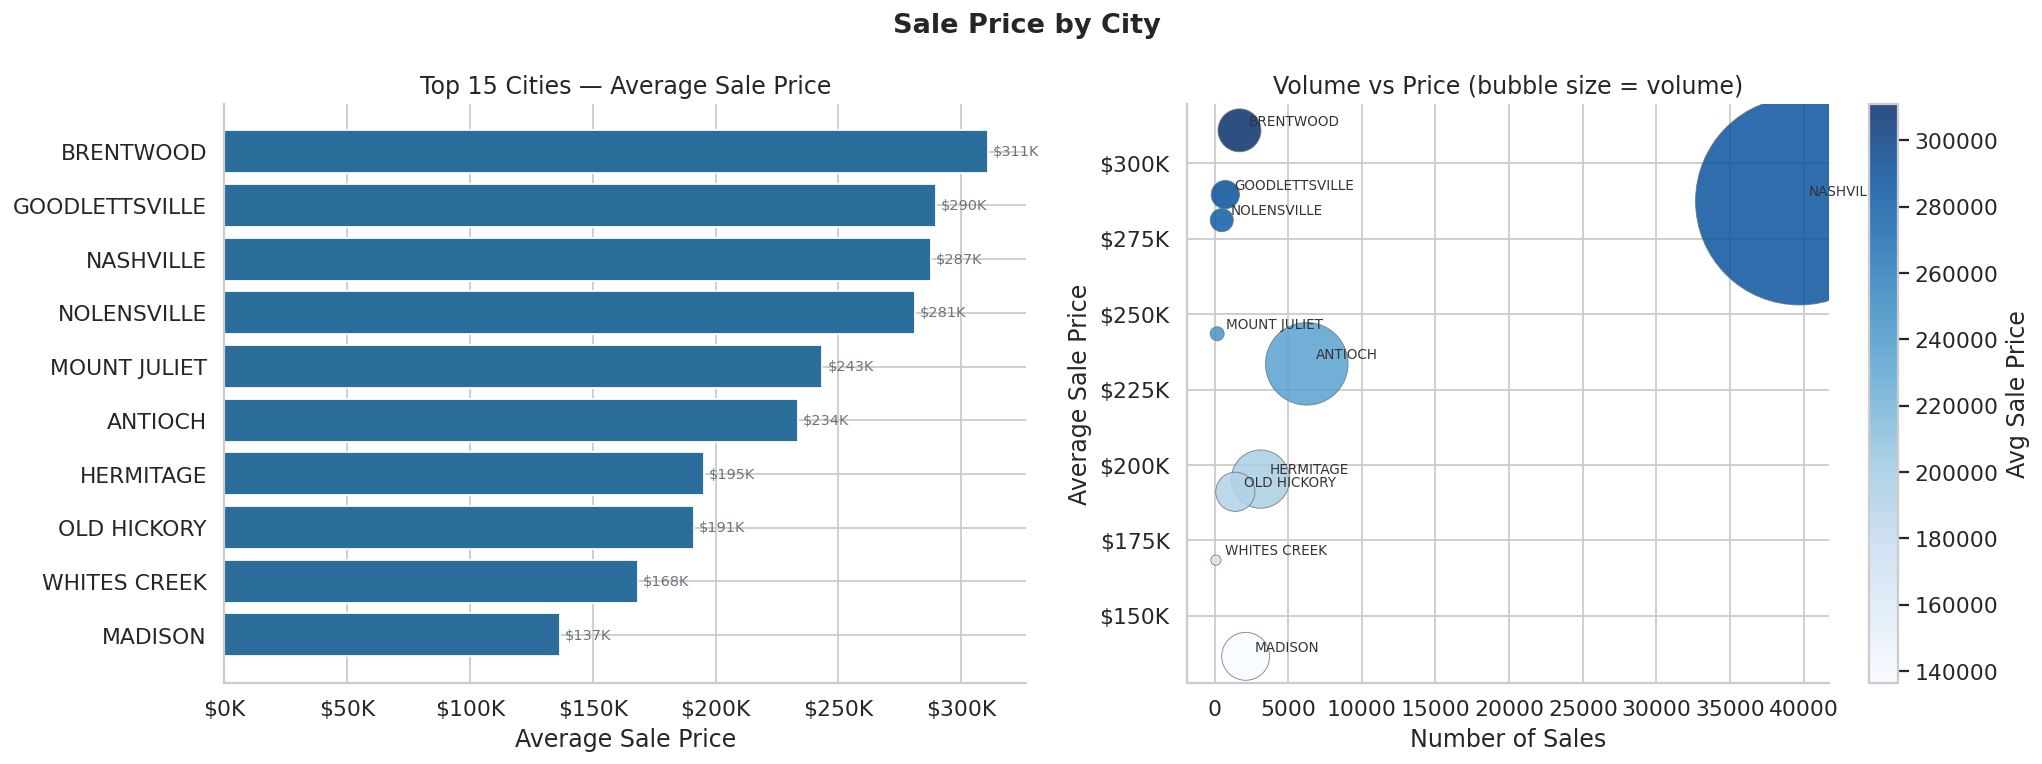

📌 Insight: The bar chart reveals which Nashville-area cities are premium markets. The bubble chart shows whether high-price cities also have high volume — or whether they are niche luxury micro-markets with few transactions, which matters for statistical reliability.


In [9]:
# ── Top 15 cities by transaction volume ───────────────────────────────────────
top_cities = (
    eda.groupby('PropertyCity')['SalePrice']
    .agg(avg_price='mean', count='count', median_price='median')
    .query('count >= 20')          # exclude cities with < 20 sales (statistically thin)
    .sort_values('avg_price', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sale Price by City', fontsize=15, fontweight='bold')

# ── Left: average price bar chart ────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(
    top_cities['PropertyCity'],
    top_cities['avg_price'],
    color=PRIMARY, edgecolor='white'
)
ax.invert_yaxis()   # highest at top
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Average Sale Price')
ax.set_title('Top 15 Cities — Average Sale Price')

# Annotate bars
for bar, val in zip(bars, top_cities['avg_price']):
    ax.text(val + 2000, bar.get_y() + bar.get_height() / 2,
            f'${val/1e3:.0f}K', va='center', fontsize=8, color=NEUTRAL)

# ── Right: count vs avg price bubble chart ───────────────────────────────────
ax2 = axes[1]
scatter = ax2.scatter(
    top_cities['count'],
    top_cities['avg_price'],
    s=top_cities['count'] / 3,
    c=top_cities['avg_price'],
    cmap='Blues', edgecolors=NEUTRAL, linewidths=0.5, alpha=0.85
)
for _, row in top_cities.iterrows():
    ax2.annotate(
        row['PropertyCity'],
        (row['count'], row['avg_price']),
        textcoords='offset points', xytext=(5, 3),
        fontsize=7.5, color='#333'
    )
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.set_xlabel('Number of Sales')
ax2.set_ylabel('Average Sale Price')
ax2.set_title('Volume vs Price (bubble size = volume)')
plt.colorbar(scatter, ax=ax2, label='Avg Sale Price')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_saleprice_by_city.png', bbox_inches='tight')
plt.show()

print('📌 Insight: The bar chart reveals which Nashville-area cities are premium '
      'markets. The bubble chart shows whether high-price cities also have '
      'high volume — or whether they are niche luxury micro-markets with few '
      'transactions, which matters for statistical reliability.')

---
## 📈 Section 5 — Bivariate Analysis: TotalValue vs SalePrice

**What to look for:** how well assessed value predicts actual sale price; deviations reveal under/over-valued properties.

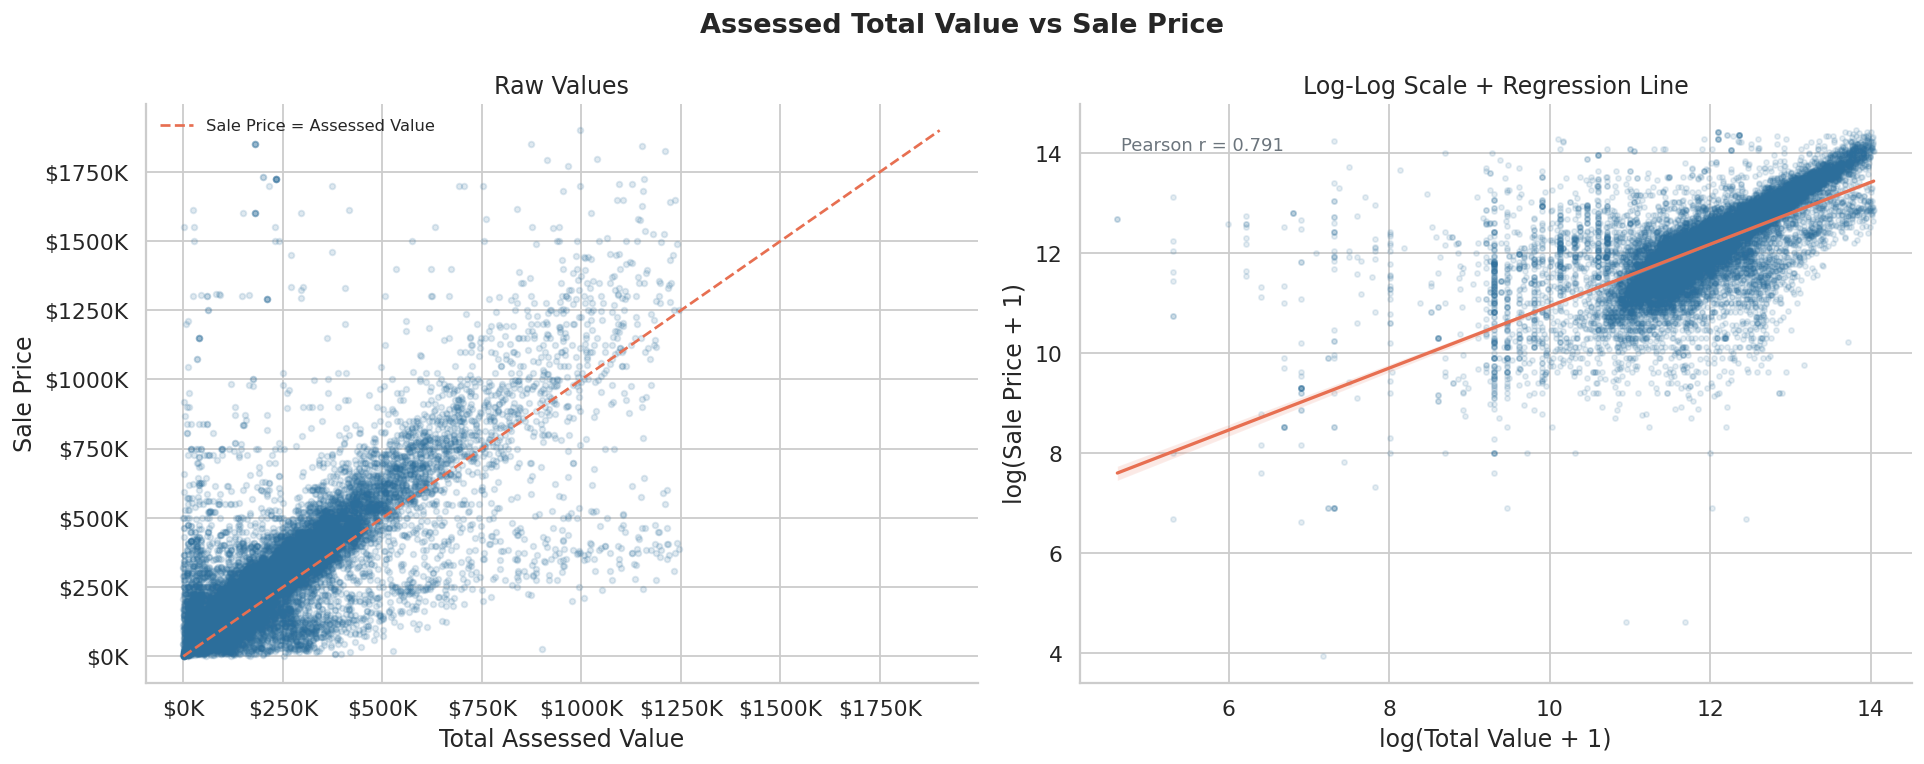

📌 Insight: Pearson r = 0.791 — assessed value and sale price are strongly correlated. Points above the dashed line sold for more than their assessed value (common in hot neighbourhoods); points below may indicate distressed sales.


In [10]:
# Filter to rows where both values are present and positive
scatter_df = eda.dropna(subset=['TotalValue', 'SalePrice'])
scatter_df = scatter_df[(scatter_df['TotalValue'] > 0) & (scatter_df['SalePrice'] > 0)]

# Cap TotalValue at its 99th percentile too (same outlier logic)
TV99 = scatter_df['TotalValue'].quantile(0.99)
scatter_df = scatter_df[scatter_df['TotalValue'] <= TV99]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Assessed Total Value vs Sale Price', fontsize=15, fontweight='bold')

# ── Left: raw scatter ─────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    scatter_df['TotalValue'], scatter_df['SalePrice'],
    alpha=0.15, s=10, color=PRIMARY
)
# Perfect-parity reference line (sale price == assessed value)
lim = max(scatter_df['TotalValue'].max(), scatter_df['SalePrice'].max())
ax.plot([0, lim], [0, lim], color=ACCENT, linestyle='--',
        linewidth=1.5, label='Sale Price = Assessed Value')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Total Assessed Value')
ax.set_ylabel('Sale Price')
ax.set_title('Raw Values')
ax.legend(frameon=False, fontsize=9)

# ── Right: log-log scatter + regression ──────────────────────────────────────
ax2 = axes[1]
sns.regplot(
    x=np.log1p(scatter_df['TotalValue']),
    y=np.log1p(scatter_df['SalePrice']),
    scatter_kws={'alpha': 0.12, 's': 8, 'color': PRIMARY},
    line_kws={'color': ACCENT, 'linewidth': 1.8},
    ax=ax2
)
ax2.set_xlabel('log(Total Value + 1)')
ax2.set_ylabel('log(Sale Price + 1)')
ax2.set_title('Log-Log Scale + Regression Line')

# Correlation coefficient
corr = scatter_df[['TotalValue','SalePrice']].corr().iloc[0,1]
ax2.text(0.05, 0.92, f'Pearson r = {corr:.3f}',
         transform=ax2.transAxes, fontsize=10, color=NEUTRAL)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_totalvalue_vs_saleprice.png', bbox_inches='tight')
plt.show()

print(f'📌 Insight: Pearson r = {corr:.3f} — assessed value and sale price are '
      f'{"strongly" if corr > 0.7 else "moderately"} correlated. '
      'Points above the dashed line sold for more than their assessed value '
      '(common in hot neighbourhoods); points below may indicate distressed sales.')

---
## 🏗️ Section 6 — Temporal Analysis: YearBuilt vs SalePrice

**What to look for:** do newer builds command higher prices? Is there a vintage premium for historic homes?

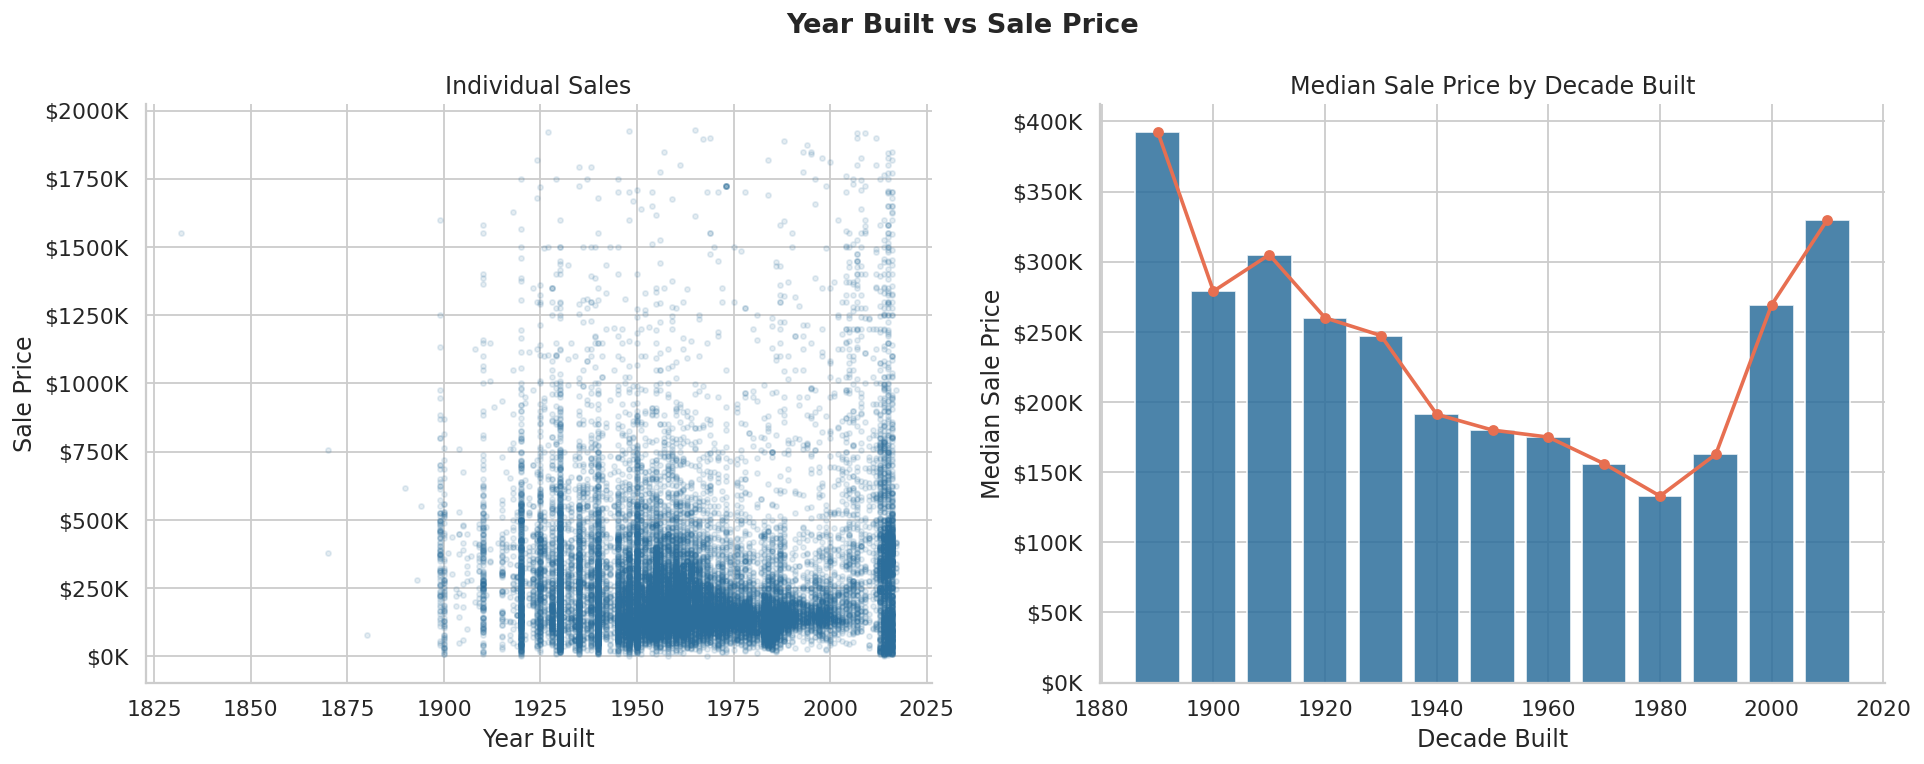

📌 Insight: The decade chart reveals whether Nashville buyers pay a new-construction premium (rising trend toward recent decades) or a vintage premium (bump in early 1900s properties). Dips in certain decades can reflect era-specific build quality or neighbourhood gentrification patterns.


In [11]:
year_df = eda.dropna(subset=['YearBuilt', 'SalePrice'])
year_df = year_df[
    (year_df['YearBuilt'] >= 1800) &
    (year_df['YearBuilt'] <= 2023) &
    (year_df['SalePrice']  > 0)
]

# Decade bins for the trend line
year_df = year_df.copy()
year_df['Decade'] = (year_df['YearBuilt'] // 10 * 10).astype(int)
decade_agg = (
    year_df.groupby('Decade')['SalePrice']
    .agg(median_price='median', count='count')
    .query('count >= 10')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Year Built vs Sale Price', fontsize=15, fontweight='bold')

# ── Left: scatter ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(
    year_df['YearBuilt'], year_df['SalePrice'],
    alpha=0.12, s=8, color=PRIMARY
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Year Built')
ax.set_ylabel('Sale Price')
ax.set_title('Individual Sales')

# ── Right: median price per decade ───────────────────────────────────────────
ax2 = axes[1]
ax2.bar(
    decade_agg['Decade'], decade_agg['median_price'],
    width=8, color=PRIMARY, edgecolor='white', alpha=0.85
)
ax2.plot(
    decade_agg['Decade'], decade_agg['median_price'],
    color=ACCENT, linewidth=2, marker='o', markersize=5
)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.set_xlabel('Decade Built')
ax2.set_ylabel('Median Sale Price')
ax2.set_title('Median Sale Price by Decade Built')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_yearbuilt_vs_saleprice.png', bbox_inches='tight')
plt.show()

print('📌 Insight: The decade chart reveals whether Nashville buyers pay a '
      'new-construction premium (rising trend toward recent decades) or a '
      'vintage premium (bump in early 1900s properties). '
      'Dips in certain decades can reflect era-specific build quality or '
      'neighbourhood gentrification patterns.')

---
## 🛏️ Section 7 — Categorical Analysis: Bedrooms vs SalePrice

**What to look for:** expected price uplift per bedroom; diminishing returns at higher counts; outliers by bedroom band.

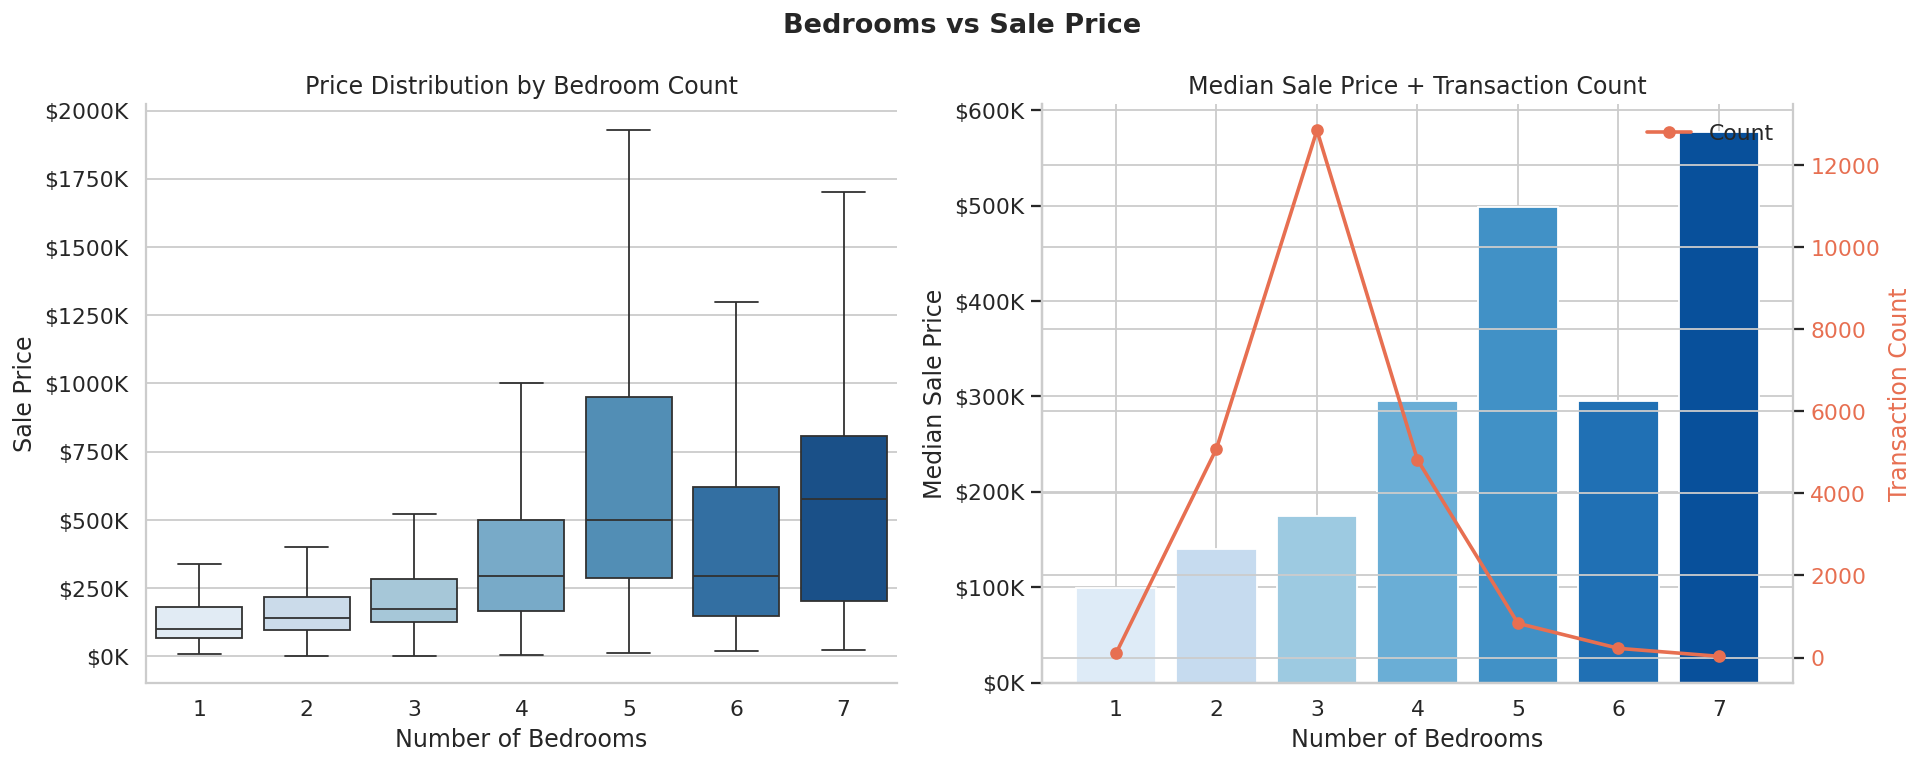

📌 Insight: The box plot shows both the central tendency and spread of prices within each bedroom band. Wide IQR ranges in higher bedroom counts suggest greater price variability (luxury vs standard finishes). The dual-axis chart reveals where most transactions concentrate — 3-bedroom homes typically dominate Nashville's resale market.


In [12]:
bed_df = eda.dropna(subset=['Bedrooms', 'SalePrice'])
bed_df = bed_df[
    (bed_df['Bedrooms'] >= 1) &
    (bed_df['Bedrooms'] <= 7)     # exclude rare extreme counts
].copy()
bed_df['Bedrooms'] = bed_df['Bedrooms'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Bedrooms vs Sale Price', fontsize=15, fontweight='bold')

# ── Left: box plot ────────────────────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=bed_df, x='Bedrooms', y='SalePrice',
    palette='Blues', showfliers=False,   # hide per-box outliers (already capped at P99)
    ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Sale Price')
ax.set_title('Price Distribution by Bedroom Count')

# ── Right: median + count summary ────────────────────────────────────────────
bed_summary = (
    bed_df.groupby('Bedrooms')['SalePrice']
    .agg(median_price='median', count='count')
    .reset_index()
)

ax2 = axes[1]
color_list = sns.color_palette('Blues', n_colors=len(bed_summary))
bars = ax2.bar(
    bed_summary['Bedrooms'].astype(str),
    bed_summary['median_price'],
    color=color_list, edgecolor='white'
)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.set_xlabel('Number of Bedrooms')
ax2.set_ylabel('Median Sale Price')
ax2.set_title('Median Sale Price + Transaction Count')

# Secondary axis: transaction count
ax3 = ax2.twinx()
ax3.plot(
    bed_summary['Bedrooms'].astype(str),
    bed_summary['count'],
    color=ACCENT, linewidth=2, marker='o', markersize=6, label='Count'
)
ax3.set_ylabel('Transaction Count', color=ACCENT)
ax3.tick_params(axis='y', labelcolor=ACCENT)
ax3.spines['right'].set_visible(True)
ax3.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_bedrooms_vs_saleprice.png', bbox_inches='tight')
plt.show()

print('📌 Insight: The box plot shows both the central tendency and spread of '
      'prices within each bedroom band. Wide IQR ranges in higher bedroom counts '
      'suggest greater price variability (luxury vs standard finishes). '
      'The dual-axis chart reveals where most transactions concentrate — '
      '3-bedroom homes typically dominate Nashville\'s resale market.')

---
## 🔥 Section 8 — Correlation Heatmap of Numerical Features

**What to look for:** multi-collinearity between value components; features most correlated with SalePrice (candidates for a predictive model).

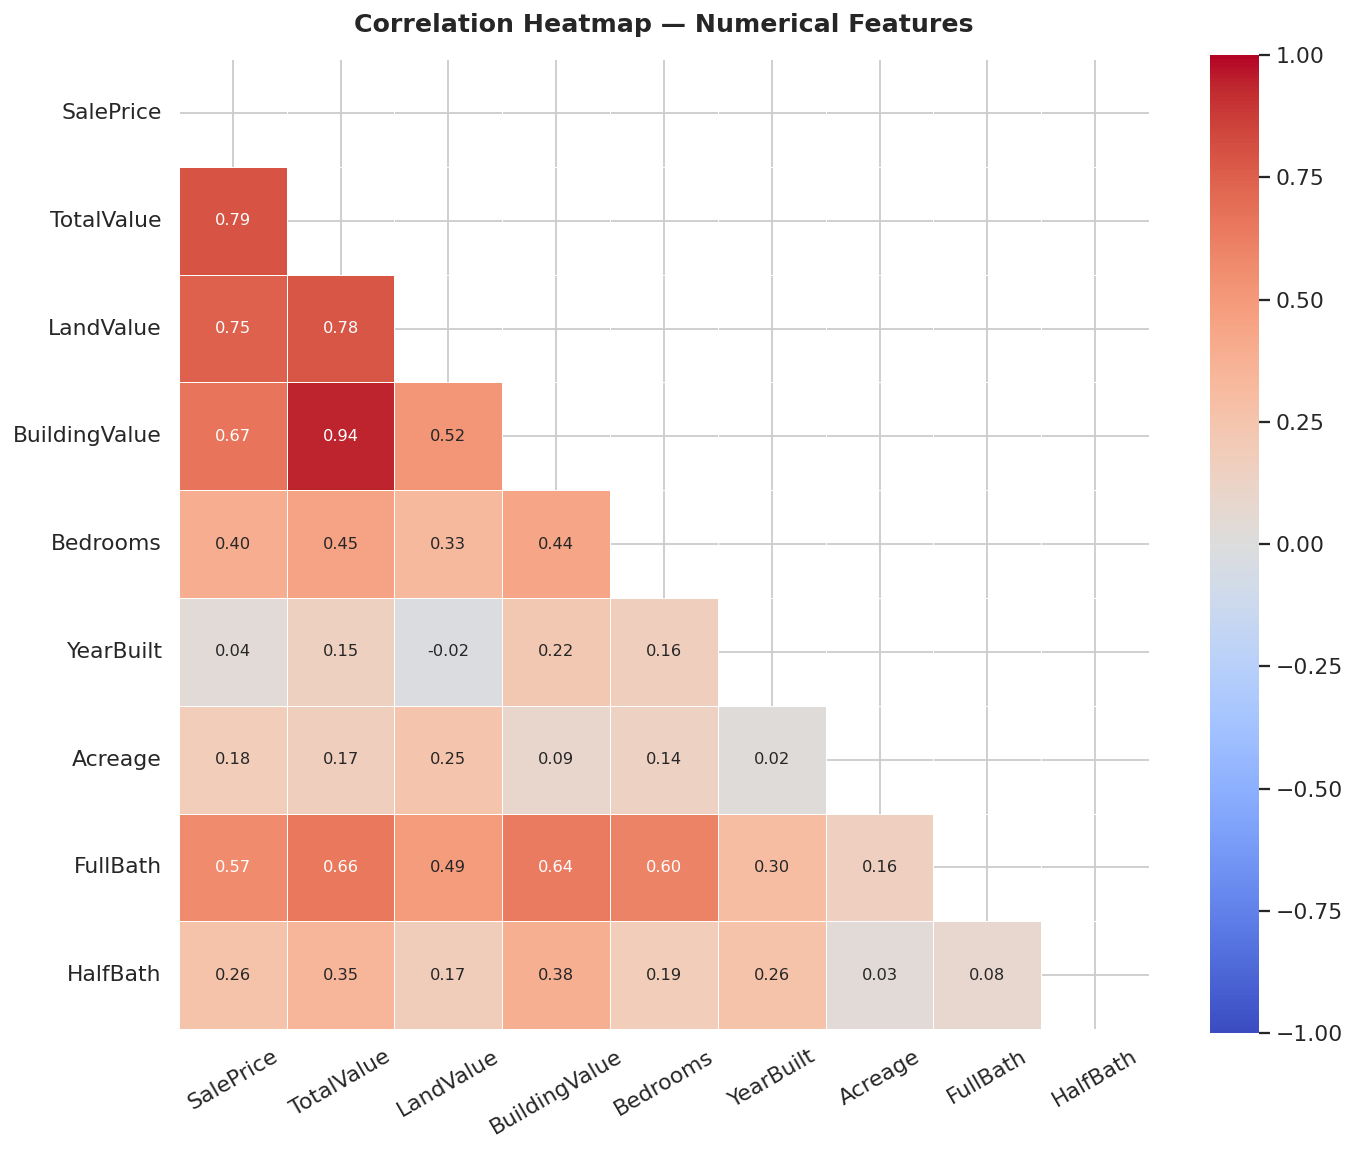

Top features correlated with SalePrice:
  TotalValue           0.790
  LandValue            0.747
  BuildingValue        0.669
  FullBath             0.569
  Bedrooms             0.397
  HalfBath             0.260
  Acreage              0.182
  YearBuilt            0.038

📌 Insight: TotalValue, LandValue, and BuildingValue are expected to correlate with SalePrice — they are components of assessed value. High inter-feature correlation (e.g. LandValue ↔ BuildingValue) signals multi-collinearity to account for before building a regression model. Features with low correlation to SalePrice (near 0) have weak standalone predictive power.


In [13]:
corr_cols = [c for c in num_cols if c in eda.columns]
corr_matrix = eda[corr_cols].corr()

# Mask the upper triangle (avoid redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# ── Top correlations with SalePrice ──────────────────────────────────────────
top_corr = (
    corr_matrix['SalePrice']
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
)
print('Top features correlated with SalePrice:')
for feat, val in top_corr.items():
    print(f'  {feat:<20} {val:.3f}')

print()
print('📌 Insight: TotalValue, LandValue, and BuildingValue are expected to '
      'correlate with SalePrice — they are components of assessed value. '
      'High inter-feature correlation (e.g. LandValue ↔ BuildingValue) signals '
      'multi-collinearity to account for before building a regression model. '
      'Features with low correlation to SalePrice (near 0) have weak '
      'standalone predictive power.')

---
## 💼 Section 9 — Power BI–Ready Export

In [16]:
# ── Build Power BI version ────────────────────────────────────────────────────
# Power BI requirements:
#   • No spaces in column names (use underscores)
#   • Dates as YYYY-MM-DD strings (Power BI auto-parses these)
#   • No special characters in column headers
#   • Numeric columns fully cast (no mixed-type columns)

pbi = df.copy()

# 1. Normalise column names
pbi.columns = (
    pbi.columns
    .str.strip()
    .str.replace(r'[^\w]', '_', regex=True)  # replace non-alphanumeric with _
    .str.replace(r'_+', '_', regex=True)      # collapse consecutive underscores
    .str.strip('_')
)

# 2. Ensure SaleDate is a proper date string
if 'SaleDate' in pbi.columns:
    pbi['SaleDate'] = pd.to_datetime(pbi['SaleDate'], errors='coerce').dt.strftime('%Y-%m-%d')

# 3. Derive calculated columns useful in Power BI DAX measures
if {'SalePrice', 'TotalValue'}.issubset(pbi.columns):
    pbi['PriceToValue_Ratio'] = (
        pbi['SalePrice'] / pbi['TotalValue'].replace(0, np.nan)
    ).round(4)

if 'YearBuilt' in pbi.columns:
    pbi['PropertyAge'] = (2024 - pbi['YearBuilt']).clip(lower=0)

if 'SaleDate' in pbi.columns:
    pbi['SaleYear']  = pd.to_datetime(pbi['SaleDate'], errors='coerce').dt.year
    pbi['SaleMonth'] = pd.to_datetime(pbi['SaleDate'], errors='coerce').dt.month
    pbi['SaleQuarter'] = pd.to_datetime(pbi['SaleDate'], errors='coerce').dt.quarter

# 4. Cast numeric columns explicitly
numeric_to_cast = ['SalePrice', 'TotalValue', 'LandValue', 'BuildingValue',
                   'Acreage', 'Bedrooms', 'YearBuilt', 'FullBath', 'HalfBath']
for col in numeric_to_cast:
    if col in pbi.columns:
        pbi[col] = pd.to_numeric(pbi[col], errors='coerce')

# 5. Export
pbi_path = PROCESSED_DIR / r'C:\Users\noahi\Documents\Git\Noah_Portofilio-\project_1\data\processed\nashville_housing_powerbi.csv'
pbi.to_csv(pbi_path, index=False, encoding='utf-8-sig')  # utf-8-sig ensures Excel/PBI reads UTF-8 correctly

print(f'✅ Power BI CSV exported → {pbi_path}')
print(f'   Rows   : {len(pbi):,}')
print(f'   Columns: {len(pbi.columns)}')
print(f'   New columns added: PriceToValue_Ratio, PropertyAge, SaleYear, SaleMonth, SaleQuarter')
display(pbi.head(3))

✅ Power BI CSV exported → C:\Users\noahi\Documents\Git\Noah_Portofilio-\project_1\data\processed\nashville_housing_powerbi.csv
   Rows   : 56,373
   Columns: 26
   New columns added: PriceToValue_Ratio, PropertyAge, SaleYear, SaleMonth, SaleQuarter


,UniqueID,ParcelID,SaleDate,SalePrice,LegalReference,SoldAsVacant,PropertyStreet,PropertyCity,OwnerName,OwnerStreet,...,TotalValue,YearBuilt,Bedrooms,FullBath,HalfBath,PriceToValue_Ratio,PropertyAge,SaleYear,SaleMonth,SaleQuarter
0,122,105 13 0 349.00,2013-01-02,225000.0,20130107-0001749,No,924 WALDKIRCH AVE,NASHVILLE,"THOMAS, JOHN HARRISON & CAMERON, VICTORIA RAYE",924 WALDKIRCH AVE,...,245200.0,1940.0,2.0,1.0,0.0,0.9176,84.0,2013,1,1
1,189,142 09 0H 065.00,2013-01-02,135000.0,20130111-0003886,No,9135 SAWYER BROWN RD,NASHVILLE,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,1,1
2,204,159 00 0 261.00,2013-01-02,1365000.0,20130104-0001158,No,5442 GRANNY WHITE PIKE,BRENTWOOD,"HAMMAN, JACO INTER VIVOS REVOCABLE TRUST",5442 GRANNY WHITE PIKE,...,1465500.0,2006.0,4.0,4.0,1.0,0.9314,18.0,2013,1,1


---
## 📋 EDA Summary

| Chart | Key Finding |
|-------|-------------|
| SalePrice Distribution | Right-skewed; median < mean due to luxury outliers |
| Avg SalePrice by City | Significant price variation across Nashville suburbs |
| TotalValue vs SalePrice | Strong positive correlation; deviations flag deal vs distress |
| YearBuilt vs SalePrice | New builds and historic homes often command premiums |
| Bedrooms vs SalePrice | Price scales with bedrooms; 3-bed dominates volume |
| Correlation Heatmap | Value components highly inter-correlated; watch for multicollinearity |

---

### Next Steps

- **Power BI:** Connect to `nashville_housing_powerbi.csv` and build a dashboard with slicers on `PropertyCity`, `SaleYear`, and `Bedrooms`.
- **Modelling:** Use `TotalValue`, `Bedrooms`, `PropertyAge`, `PropertyCity` as features in a regression model to predict `SalePrice`.
- **Geospatial:** If lat/lon data is available, plot a choropleth map of median SalePrice by zip code.
